# Test estilométricos clásicos

Este notebook se centra en la aplicación de técnicas de estilometría clásicas para analizar los textos de los autores seleccionados. Estas técnicas incluyen:

1. El **test de las curvas características de composición de Mendenhall** (_Mendenhall’s Characteristic Curves of Composition_)
2. El **método del chi-cuadrado de Kilgariff** (_Kilgariff’s Chi-Squared Method_)
3. El **método de la distancia de Burrows** (_Burrows’s Delta Method_)

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

from whodunit_stylometry.constants import AUTHORS_ABREV_MAP, AUTHORS_NORM_MAP, STOPWORDS
from whodunit_stylometry.utils.data_utils import load_corpus_by_dataframe, load_test_by_dataframe, get_work_key
from whodunit_stylometry.utils.nlp_utils import (
    CustomTokenizer,
    fix_gutenberg_linebreaks,
    is_alpha_tokens,
    normalize_text_for_tokenization,
)
from whodunit_stylometry.utils.stats_utils import (
    align_distributions,
    classify_test_works_burrows,
    classify_test_works_by_average_curve,
    classify_test_works_kilgariff,
    compute_average_curve,
    distance_matrix,
    get_pairwise_burrows_contributions,
    get_pairwise_contributions,
    word_length_distributions_random_blocks,
)
from whodunit_stylometry.utils.plot_utils import plot_word_length_distributions

## Carga del corpus

In [2]:
# Configuración
SEED = 1
CORPUS_PATH = Path("../corpus")

In [3]:
# Cargamos los metadatos del corpus y añadimos la
# ruta a cada archivo de texto. Esto nos permitirá
# más adelante leer los textos más fácilmente.
df_meta = pd.read_csv(CORPUS_PATH / "corpus_metadata.csv", sep=";")
df_meta["file_path"] = df_meta.apply(
    lambda x: CORPUS_PATH / "hand_cleaned" / AUTHORS_NORM_MAP[x["author"]] / x["file_name"], axis=1
)
print(df_meta.shape)
df_meta.head()

(95, 13)


,file_name,author,title,year,type,detective,genre,language,country,source,license,url,file_path
0,acd-a_study_in_scarlet.txt,Arthur Conan Doyle,A Study in Scarlet,1887,novel,Sherlock Holmes,mystery,en,UK,Project Gutemberg USA,Public domain in the USA.,https://www.gutenberg.org/cache/epub/244/pg244...,../corpus/hand_cleaned/arthur_conan_doyle/acd-...
1,acd-tales_of_terror_and_mystery.txt,Arthur Conan Doyle,Tales of Terror and Mystery,1890,short stories,NaN,terror,en,UK,Project Gutemberg USA,Public domain in the USA.,https://www.gutenberg.org/cache/epub/537/pg537...,../corpus/hand_cleaned/arthur_conan_doyle/acd-...
2,acd-the_adventures_of_sherlock_holmes.txt,Arthur Conan Doyle,The Adventures of Sherlock Holmes,1892,short stories,Sherlock Holmes,mystery,en,UK,Project Gutemberg USA,Public domain in the USA.,https://www.gutenberg.org/cache/epub/1661/pg16...,../corpus/hand_cleaned/arthur_conan_doyle/acd-...
3,acd-the_case_book_of_sherlock_holmes.txt,Arthur Conan Doyle,The case-book of Sherlock Holmes,1921,short stories,Sherlock Holmes,mystery,en,UK,Project Gutemberg USA,Public domain in the USA.,https://www.gutenberg.org/cache/epub/69700/pg6...,../corpus/hand_cleaned/arthur_conan_doyle/acd-...
4,acd-the_hound_of_the_baskervilles.txt,Arthur Conan Doyle,The Hound of the Baskervilles,1901,novel,Sherlock Holmes,mystery,en,UK,Project Gutemberg USA,Public domain in the USA.,https://www.gutenberg.org/cache/epub/2852/pg28...,../corpus/hand_cleaned/arthur_conan_doyle/acd-...


In [4]:
# Nos quedamos solo con los textos de las novelas de misterio
# ya que el género influye mucho en algunos de los tests
# estilométricos clásicos que vamos a realizar a continuación.
df_meta_f = df_meta[df_meta["genre"] == "mystery"].copy()
df_meta_f.shape

(79, 13)

In [5]:
# Nos quedamos con dos textos de prueba que no son del
# género de misterio para poder evaluar la capacidad
# de los métodos para discriminar con otros géneros
df_test_nm = df_meta[df_meta["genre"] != "mystery"].groupby("author", group_keys=False).sample(n=1, random_state=SEED)

In [6]:
# Nos quedamos con una muestra de 1 texto por
# autor para probar la efectividad de los tests
# para identificar al autor de un texto desconocido.
df_test = df_meta_f.groupby("author", group_keys=False).sample(n=1, random_state=SEED)

# Original sin las obras de prueba seleccionadas
df_meta_f = df_meta_f.drop(index=df_test.index)

# Dataset de prueba con las obras de misterio y no misterio
df_test = pd.concat([df_test, df_test_nm], ignore_index=True)

df_test = df_test.reset_index(drop=True)
df_meta_f = df_meta_f.reset_index(drop=True)

In [7]:
df_test

,file_name,author,title,year,type,detective,genre,language,country,source,license,url,file_path
0,akg-room_number_3_and_other_detective_stories.txt,Anna Katharine Green,"Room Number 3, and Other Detective Stories",1913,short stories,NaN,mystery,en,USA,Project Gutemberg USA,Public domain in the USA.,https://www.gutenberg.org/cache/epub/31578/pg3...,../corpus/hand_cleaned/anna_katharine_green/ak...
1,acd-the_hound_of_the_baskervilles.txt,Arthur Conan Doyle,The Hound of the Baskervilles,1901,novel,Sherlock Holmes,mystery,en,UK,Project Gutemberg USA,Public domain in the USA.,https://www.gutenberg.org/cache/epub/2852/pg28...,../corpus/hand_cleaned/arthur_conan_doyle/acd-...
2,am-adventures_of_martin_hewitt.txt,Arthur Morrison,Adventures of Martin Hewit,1896,short stories,Martin Hewit,mystery,en,UK,Project Gutemberg USA,Public domain in the USA.,https://www.gutenberg.org/cache/epub/59319/pg5...,../corpus/hand_cleaned/arthur_morrison/am-adve...
3,gkc-the_poet_and_the_lunatics.txt,Gilbert Keith Chesterton,The Poet and The Lunatics,1929,short stories,NaN,mystery,en,UK,Project Gutemberg AU,Public domain in the USA.,https://gutenberg.net.au/ebooks09/0900711.txt,../corpus/hand_cleaned/gilbert_keith_chesterto...
4,raf-the_shadow_of_the_wolf.txt,Richard Austin Freeman,The shadow of the Wolf,1925,novel,Dr. Thorndyke,mystery,en,UK,Project Gutemberg USA,Public domain in the USA.,https://www.gutenberg.org/cache/epub/75244/pg7...,../corpus/hand_cleaned/richard_austin_freeman/...
5,wc-the_haunted_hotel.txt,Wilkie Collins,The Haunted Hotel,1878,novel,NaN,mystery,en,UK,Project Gutemberg USA,Public domain in the USA.,https://www.gutenberg.org/cache/epub/170/pg170...,../corpus/hand_cleaned/wilkie_collins/wc-the_h...
6,akg-to_the_minute.txt,Anna Katharine Green,To the Minute,1916,novel,NaN,fiction,en,USA,Project Gutemberg AU,Public domain in the USA.,https://gutenberg.net.au/ebooks17/1701091h.html,../corpus/hand_cleaned/anna_katharine_green/ak...
7,acd-the_white_company.txt,Arthur Conan Doyle,The White Company,1891,novel,NaN,historical,en,UK,Project Gutemberg USA,Public domain in the USA.,https://www.gutenberg.org/cache/epub/903/pg903...,../corpus/hand_cleaned/arthur_conan_doyle/acd-...
8,am-the_hole_in_the_wall.txt,Arthur Morrison,The Hole in the Wall,1902,novel,NaN,fiction,en,UK,Project Gutemberg USA,Public domain in the USA.,https://www.gutenberg.org/cache/epub/34538/pg3...,../corpus/hand_cleaned/arthur_morrison/am-the_...
9,gkc-the_napoleon_of_notting_hill.txt,Gilbert Keith Chesterton,The Napoleon of Notting Hill,1904,novel,NaN,fiction,en,UK,Project Gutemberg USA,Public domain in the USA.,https://www.gutenberg.org/cache/epub/20058/pg2...,../corpus/hand_cleaned/gilbert_keith_chesterto...


In [8]:
# Cargamos el corpus de los autores en un diccionario
corpus_by_author = load_corpus_by_dataframe(df_meta_f)
corpus_by_author.keys()

dict_keys(['Anna Katharine Green', 'Arthur Conan Doyle', 'Arthur Morrison', 'Gilbert Keith Chesterton', 'Richard Austin Freeman', 'Wilkie Collins'])

In [9]:
# Contamos el número de textos por autor para
# ver si el dataset está balanceado o no
df_meta["author"].value_counts()

author
Anna Katharine Green        34
Gilbert Keith Chesterton    18
Richard Austin Freeman      15
Arthur Conan Doyle          12
Wilkie Collins              10
Arthur Morrison              6
Name: count, dtype: int64

In [10]:
# Calculamos la longitud de cada corpus por autor en caracteres
lengths = [len(corpus_by_author[author]) for author in AUTHORS_ABREV_MAP.keys()]

corpus_lengths_df = pd.DataFrame({"author": AUTHORS_ABREV_MAP.values(), "length_in_chars": lengths}).sort_values(
    "length_in_chars", ascending=False
)
corpus_lengths_df

,author,length_in_chars
0,A.K. Green,13369581
4,R.A. Freeman,5767855
3,G.K. Chesterton,4066012
5,W. Collins,3190033
1,A.C. Doyle,3034286
2,A. Morrison,1310897


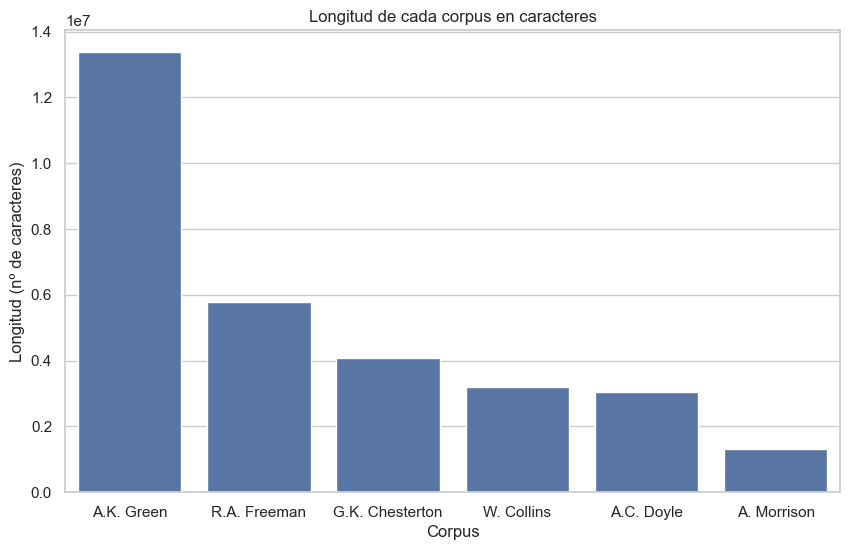

In [11]:
plt.figure(figsize=(10, 6))
sns.barplot(data=corpus_lengths_df, x="author", y="length_in_chars")
plt.xlabel("Corpus")
plt.ylabel("Longitud (nº de caracteres)")
plt.title("Longitud de cada corpus en caracteres")
plt.show()

Como vemos, el dataset está bastante desbalanceado en cuanto a número de caracteres/obras por autor, lo que puede afectar a la efectividad de los tests estilométricos.

In [12]:
# Mostramos los primeros 200 caracteres de
# cada corpus para verificar su contenido
for author in AUTHORS_ABREV_MAP.keys():
    print(corpus_by_author[author][:200])
    print("=" * 40)

7 TO 12.

A DETECTIVE STORY.


“Clarke?”

“Yes, sir.”

“Another entrance through a second-story window. A detective wanted
right off. Better hurry up there, —— East Seventy-third Street.”

“All right,
A STUDY IN SCARLET



PART I.


(_Being a reprint from the Reminiscences of_ JOHN H. WATSON, M.D.,
_Late of the Army Medical Department._)




CHAPTER I.
MR. SHERLOCK HOLMES.


In the year 1878 I took
CHRONICLES OF MARTIN HEWITT



THE IVY COTTAGE MYSTERY.


I had been working double tides for a month: at night on my morning
paper, as usual; and in the morning on an evening paper as _locum
tenens_ 
FOUR FAULTLESS FELONS


CLUE OF THE PRESSMAN

I PROLOGUE OF THE PRESSMAN

MR. ASA LEE PINION, of the Chicago Comet, had crossed half of America,
the whole of the Atlantic, and eventually even Piccadil
A SILENT WITNESS

CHAPTER I.
THE BEGINNING OF THE MYSTERY

The history upon which I am now embarking abounds in incidents so
amazing that, as I look back on them, a something approaching to
scepti

## Limpieza y normalización del texto

Para más información sobre la limpieza y normalización del texto, consultar el apéndice correspondiente en la memoria (`Apéndice II - Normalización de los textos`).

In [13]:
# Normalizamos el texto de cada corpus
corpus_by_author_norm = {}

for author in AUTHORS_ABREV_MAP.keys():
    normalized_text = normalize_text_for_tokenization(fix_gutenberg_linebreaks(corpus_by_author[author]))
    corpus_by_author_norm[author] = normalized_text
    unique_chars = set(normalized_text)
    print(f"{author}: {unique_chars} ({len(unique_chars)})")

Anna Katharine Green: {'z', 'n', 'œ', 'l', 'q', 'ä', 'i', 'P', '2', 'x', '&', 'h', 'G', 'v', 'w', 'à', 'X', 'A', 't', '3', 'k', 'O', 'U', 'e', '}', '6', 'B', 'ô', ']', 'â', 'Æ', '"', 'y', '{', 'ç', 'K', '-', 'æ', 'N', '!', 'a', 'é', 'm', '7', '—', 'L', ';', 'F', 'V', 'b', 'J', ')', 'S', '?', '\n', 'å', '(', '*', 'r', 'ï', 'c', 'D', 'M', '$', 'Y', ',', ' ', 'g', '0', 'T', 'f', '9', 'R', 'Z', "'", 'E', '[', '5', 'o', ':', 'è', 'd', 'ö', '.', 'W', 'C', 'I', 'H', '1', 'u', 's', 'Q', 'ê', 'j', 'ë', '4', 'p', '8'} (98)
Arthur Conan Doyle: {'z', 'n', 'œ', 'l', 'q', 'i', 'P', '2', 'x', '&', 'h', 'G', '|', 'v', 'w', 'à', 'X', 'A', 't', '3', 'k', 'O', 'ñ', 'U', 'e', '6', 'B', 'ô', ']', 'â', '"', 'y', 'ç', 'K', '-', 'æ', 'N', '!', 'a', 'é', 'm', '7', '—', 'L', ';', 'F', 'V', 'b', 'J', ')', 'S', '?', '\n', '(', 'r', 'ï', 'c', 'û', 'D', 'M', 'î', 'Y', ',', ' ', 'g', '½', '0', 'T', '°', 'ü', 'f', '9', 'R', 'Z', "'", 'E', '[', '5', '£', 'o', ':', 'è', 'd', 'ö', '.', 'W', 'C', 'I', 'H', '1', 'u', 's',

In [14]:
for author in AUTHORS_ABREV_MAP.keys():
    print(corpus_by_author_norm[author][:200])
    print("=" * 40)

7 TO 12.

A DETECTIVE STORY.

"Clarke?"

"Yes, sir."

"Another entrance through a second-story window. A detective wanted right off. Better hurry up there, — East Seventy-third Street."

"All right, s
A STUDY IN SCARLET

PART I.

(Being a reprint from the Reminiscences of JOHN H. WATSON, M.D., Late of the Army Medical Department.)

CHAPTER I. MR. SHERLOCK HOLMES.

In the year 1878 I took my degree 
CHRONICLES OF MARTIN HEWITT

THE IVY COTTAGE MYSTERY.

I had been working double tides for a month: at night on my morning paper, as usual; and in the morning on an evening paper as locum tenens for a
FOUR FAULTLESS FELONS

CLUE OF THE PRESSMAN

I PROLOGUE OF THE PRESSMAN

MR. ASA LEE PINION, of the Chicago Comet, had crossed half of America, the whole of the Atlantic, and eventually even Piccadill
A SILENT WITNESS

CHAPTER I. THE BEGINNING OF THE MYSTERY

The history upon which I am now embarking abounds in incidents so amazing that, as I look back on them, a something approaching to scepti

Parece que la limpieza y normalización del texto se ha realizado correctamente, no vemos caracteres extraños ni problemas evidentes en el texto.

## Tokenización de los textos

Para más información sobre la tokenización de los textos, consultar el apéndice correspondiente en la memoria (`Apéndice II - Normalización de los textos`).

In [15]:
# Tokenizamos cada corpus por autor y lo
# guardamos en un nuevo diccionario
tokenizer = CustomTokenizer()

corpus_by_author_tokens = {}
for author, norm_text in corpus_by_author_norm.items():
    toks = []
    tokens_all = tokenizer.tokenize(norm_text)
    tokens_alpha = is_alpha_tokens(tokens_all, keep_alpha=True)
    toks.extend(tokens_alpha)
    corpus_by_author_tokens[author] = toks
    print(f"{author}: {toks[:20]} ... ({len(toks)} tokens)")

Anna Katharine Green: ['TO', 'A', 'DETECTIVE', 'STORY', 'Clarke', 'Yes', 'sir', 'Another', 'entrance', 'through', 'a', 'second', 'story', 'window', 'A', 'detective', 'wanted', 'right', 'off', 'Better'] ... (2467631 tokens)
Arthur Conan Doyle: ['A', 'STUDY', 'IN', 'SCARLET', 'PART', 'I.', 'Being', 'a', 'reprint', 'from', 'the', 'Reminiscences', 'of', 'JOHN', 'H.', 'WATSON', 'M.D.', 'Late', 'of', 'the'] ... (542153 tokens)
Arthur Morrison: ['CHRONICLES', 'OF', 'MARTIN', 'HEWITT', 'THE', 'IVY', 'COTTAGE', 'MYSTERY', 'I', 'had', 'been', 'working', 'double', 'tides', 'for', 'a', 'month', 'at', 'night', 'on'] ... (240381 tokens)
Gilbert Keith Chesterton: ['FOUR', 'FAULTLESS', 'FELONS', 'CLUE', 'OF', 'THE', 'PRESSMAN', 'I', 'PROLOGUE', 'OF', 'THE', 'PRESSMAN', 'MR', 'ASA', 'LEE', 'PINION', 'of', 'the', 'Chicago', 'Comet'] ... (735927 tokens)
Richard Austin Freeman: ['A', 'SILENT', 'WITNESS', 'CHAPTER', 'I.', 'THE', 'BEGINNING', 'OF', 'THE', 'MYSTERY', 'The', 'history', 'upon', 'which', 'I', '

## 1. Curvas características de composición de Mendenhall

Con el fin de estudiar la estabilidad interna del estilo de cada autor, en este apartado se emplean las **curvas características de composición de Mendenhall**, construidas a partir de la distribución de longitudes de palabra. La idea de base es que cada texto puede caracterizarse, al menos parcialmente, por la proporción de palabras de longitud 1, 2, 3, etc., y que este patrón puede actuar como una huella estilística.

Para cada autor, el procedimiento parte de su corpus ya tokenizado y extrae varios bloques contiguos aleatorios de igual tamaño. En este caso, se toman 50 bloques de 100.000 tokens cada uno. Sobre cada bloque se calcula la distribución de longitudes de palabra, es decir, se cuenta cuántas palabras tienen longitud 1, cuántas longitud 2, y así sucesivamente. Posteriormente, esos conteos se normalizan, de modo que cada bloque queda representado por una distribución de frecuencias relativas.

Cada una de estas distribuciones constituye una curva de Mendenhall para un bloque concreto del corpus. Como no todos los bloques contienen necesariamente palabras de todas las longitudes posibles, las distribuciones se alinean sobre un mismo rango fijo de longitudes. Así, cada bloque queda representado por un vector comparable con los demás, donde cada posición corresponde a una longitud de palabra determinada y las ausencias se rellenan con valor cero.

Una vez obtenidas las curvas alineadas, se calcula la **distancia de Jensen-Shannon** entre todos los pares de bloques del mismo autor. Esta medida cuantifica el grado de diferencia entre dos distribuciones de probabilidad: valores próximos a cero indican curvas muy parecidas, mientras que valores más altos reflejan una mayor divergencia. A partir de la matriz de distancias resultante, se resume la variabilidad interna del autor mediante dos estadísticas: la **media** y la **desviación típica** de las distancias.

La interpretación de estas medidas es directa. Una **distancia media baja** sugiere que los distintos fragmentos del corpus del autor presentan distribuciones de longitudes de palabra muy similares entre sí, lo que apunta a una mayor homogeneidad estilística desde este punto de vista. Por el contrario, una **distancia media alta** indica una mayor variación interna. La desviación típica, por su parte, informa sobre la regularidad de esa variación: valores bajos señalan un comportamiento más uniforme entre bloques, mientras que valores altos revelan que algunas partes del corpus se parecen mucho entre sí y otras difieren de manera más acusada.

Este análisis nos va permitir evaluar hasta qué punto la curva de Mendenhall de un autor se mantiene estable a lo largo de diferentes fragmentos de su obra. Así, no solo permite describir cómo se distribuyen las longitudes de palabra, sino también medir numéricamente hasta qué punto ese patrón se mantiene estable dentro del texto.

In [16]:
# Primero, y por curiosidad, vamos a calcular la
# longitud de la palabra más larga por autor
longest_word_by_author = {
    author: (max(tokens, key=len), len(max(tokens, key=len))) for author, tokens in corpus_by_author_tokens.items()
}
longest_word_by_author

{'Anna Katharine Green': ('IDONOTWANTTODIEBUTISURELYWILLIF', 31),
 'Arthur Conan Doyle': ('disproportionately', 18),
 'Arthur Morrison': ('characteristically', 18),
 'Gilbert Keith Chesterton': ('unconscientiousness', 19),
 'Richard Austin Freeman': ('characteristically', 18),
 'Wilkie Collins': ('misinterpretations', 18)}

Nos podría llamar la atención la palabra más larga de A. K. Green, pero comprobamos que no se trata de un error de OCR o formato, sino que realmente forma parte de una de sus obras (*The Golden Slipper and Other Problems for Violet Strange*). El resto son palabras recogidas en el diccionario de la lengua inglesa.

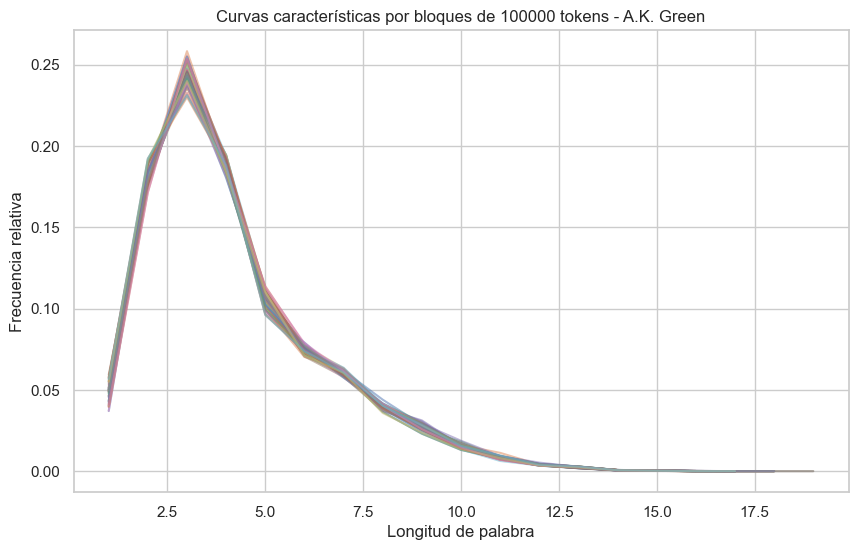

Anna Katharine Green
  Mean: 0.02102
  Std:  0.00732


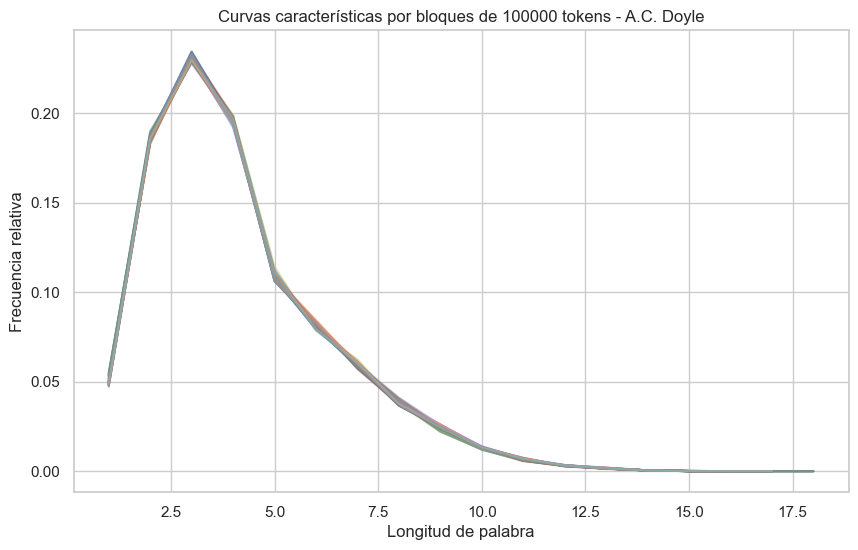

Arthur Conan Doyle
  Mean: 0.00972
  Std:  0.00333


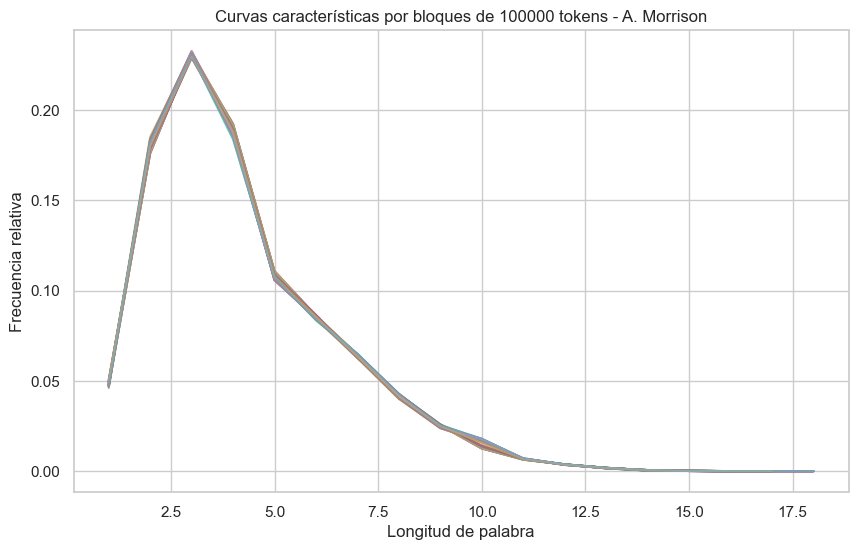

Arthur Morrison
  Mean: 0.00966
  Std:  0.00499


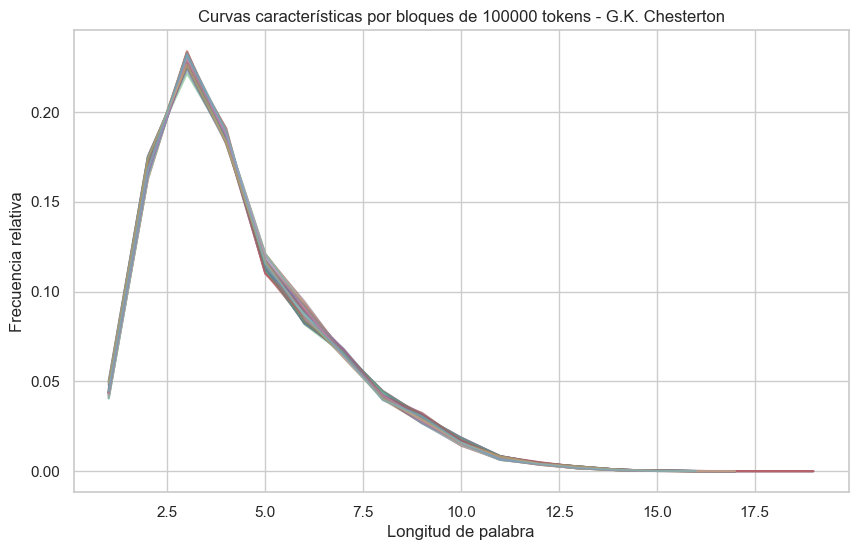

Gilbert Keith Chesterton
  Mean: 0.01567
  Std:  0.00605


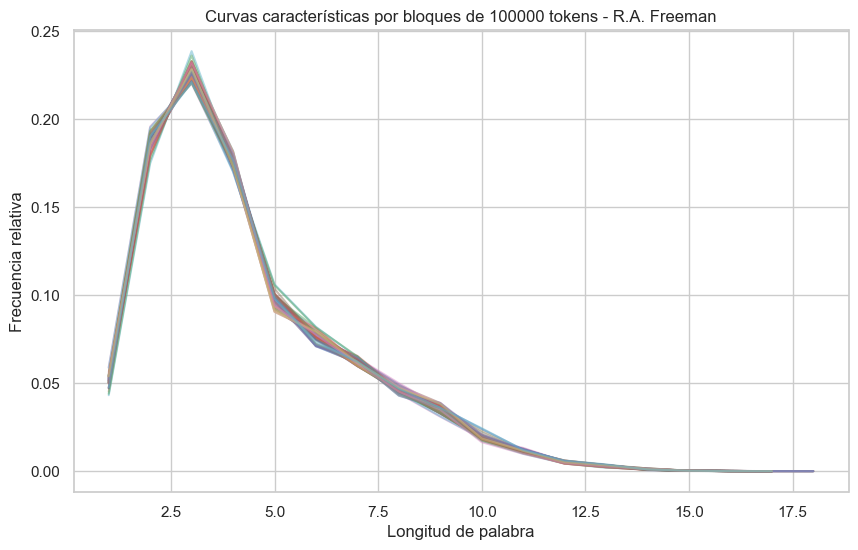

Richard Austin Freeman
  Mean: 0.01688
  Std:  0.00552


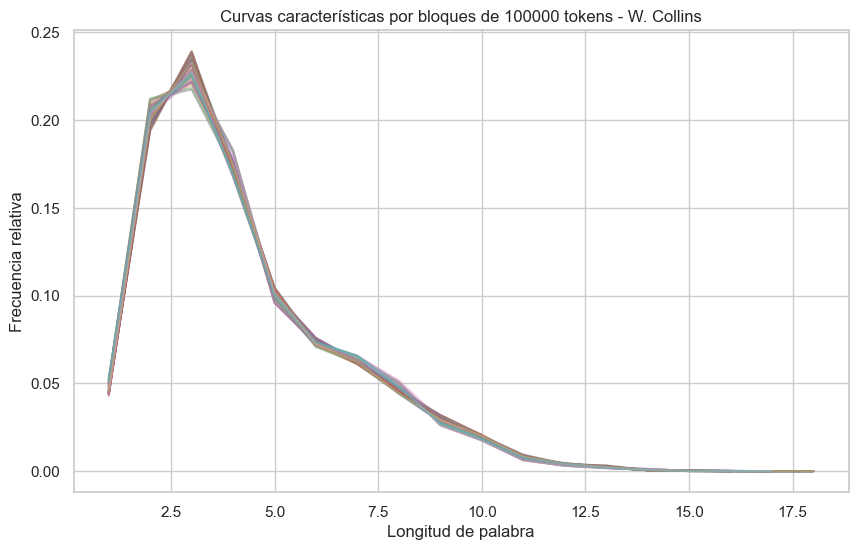

Wilkie Collins
  Mean: 0.01551
  Std:  0.00606


In [17]:
# Diccionario para guardar las distribuciones de
# longitudes de palabra de los bloques por autor
author_distributions = {}
# Diccionario para guardar las estadísticas (media
# y desviación) de las distribuciones de cada autor
author_stats = {}

BLOCK_SIZE = 100_000
N_BLOCKS = 50

for author in AUTHORS_ABREV_MAP.keys():
    # Calculamos las distribuciones de longitud de palabra
    # de los bloques aleatorios del corpus del autor
    distributions = word_length_distributions_random_blocks(
        corpus_by_author_tokens[author],
        block_size=BLOCK_SIZE,
        n_blocks=N_BLOCKS,
        seed=SEED,
    )

    author_distributions[author] = distributions

    # Dibujamos las distribuciones de longitud de palabra
    # de los bloques del autor
    plot_word_length_distributions(AUTHORS_ABREV_MAP[author], distributions, block_size=BLOCK_SIZE)

    # Alineamos las distribuciones para que tengan
    # la misma longitud en todos los bloques del autor
    aligned, lengths = align_distributions(distributions)
    # Calculamos la matriz de distancias entre los bloques
    D = distance_matrix(aligned)
    # Nos quedamos solo con el triángulo superior (sin diagonal)
    distances = D[np.triu_indices_from(D, k=1)]

    # Calculamos la media y desviación de las distancias
    # entre las distribuciones de los bloques del autor
    mean_distance = np.mean(distances)
    std_distance = np.std(distances)

    # Guardamos resultados
    author_stats[author] = {
        "mean": mean_distance,
        "std": std_distance,
    }

    print(f"{author}")
    print(f"  Mean: {mean_distance:.5f}")
    print(f"  Std:  {std_distance:.5f}")

In [18]:
# Guardamos las estadísticas en un DataFrame
# y mostramos el resultado para comparar entre autores
author_stats_df = pd.DataFrame.from_dict(author_stats, orient="index").reset_index().rename(columns={"index": "author"})

author_stats_df

,author,mean,std
0,Anna Katharine Green,0.021015,0.007323
1,Arthur Conan Doyle,0.009719,0.003331
2,Arthur Morrison,0.009660,0.004995
3,Gilbert Keith Chesterton,0.015666,0.006050
4,Richard Austin Freeman,0.016884,0.005517
5,Wilkie Collins,0.015507,0.006055


Los resultados muestran diferencias claras en la estabilidad interna de las curvas de Mendenhall entre autores. Arthur Morrison y Arthur Conan Doyle presentan la menor distancia media y la menor desviación típica, lo que indica que la distribución de longitudes de palabra de sus distintos bloques son las más homogéneas y regulares del conjunto.

En el extremo opuesto, Anna Katharine Green y Richard Austin Freeman registran las mayores distancias medias y desviaciones típicas, lo que sugiere una mayor variabilidad interna en este rasgo estilístico. Arthur Morrison, Gilbert Keith Chesterton y Wilkie Collins ocupan posiciones intermedias, con curvas relativamente estables, aunque menos uniformes que las de Morrison y Doyle.

Los resultados permiten ordenar a los autores, de mayor a menor homogeneidad interna, aproximadamente así:

**Arthur Morrison > Arthur Conan Doyle > Gilbert Keith Chesterton > Wilkie Collins > Richard Austin Freeman > Anna Katharine Green**

Esto no significa que unos autores “escriban mejor” que otros, ni tampoco que sus estilos sean más simples o más complejos. Lo que indica, de forma más precisa, es que la distribución de longitudes de palabra se mantiene con distinta estabilidad a lo largo de sus corpus. En unos casos, esa distribución funciona como una huella muy consistente y, en otros, presenta más fluctuaciones entre fragmentos.

### Curva característica media por autor

Una vez obtenidas las curvas de Mendenhall para los distintos bloques aleatorios de cada autor, el siguiente paso consiste en construir una curva característica media que resuma su comportamiento global. El objetivo ahora es disponer de una representación única por autor, calculada a partir de la información contenida en todos los bloques previamente muestreados.

La función `compute_average_curve()` recibe como entrada una lista de distribuciones de longitudes de palabra, donde cada distribución corresponde a uno de los bloques aleatorios del corpus del autor. Cada una de estas distribuciones está representada como un diccionario en el que las claves son las longitudes de palabra y los valores sus frecuencias relativas dentro del bloque.

La función recorre todas las distribuciones y acumula, para cada longitud de palabra, la suma de sus frecuencias relativas en los distintos bloques. Una vez agregadas todas las frecuencias, la suma acumulada para cada longitud se divide entre el número total de bloques. De este modo, se obtiene una frecuencia relativa media para cada longitud de palabra, es decir, una estimación del comportamiento promedio de la curva de Mendenhall del autor a lo largo de todo su corpus.

Esta curva media puede entenderse como una versión suavizada y representativa de las curvas individuales por bloque. Mientras que las curvas obtenidas antes permitían estudiar la variación interna de cada autor, la curva media resume su comportamiento general y atenúa el efecto de pequeñas variaciones o irregularidades presentes en fragmentos concretos.

Una vez calculada la curva media de cada autor, estas se almacenan en el diccionario `average_curves`. A continuación, se recopilan todas las longitudes de palabra observadas en el conjunto de autores para construir un eje horizontal común. Este paso garantiza que todas las curvas se representen sobre la misma escala y que puedan compararse visualmente de forma directa, incluso si algunos autores no presentan determinadas longitudes en su curva media.

Finalmente, mostramos una representación gráfica en la que:

- el eje `x` corresponde a la longitud de palabra
- el eje `y` representa la frecuencia relativa media
- cada línea corresponde a la curva característica media de un autor

La visualización resultante permite comparar los perfiles medios de composición de los distintos autores y detectar posibles semejanzas o diferencias en la distribución de longitudes de palabra. En este sentido, mientras que el análisis anterior se centraba en la estabilidad interna de cada autor, esta representación permite una comparación entre autores más directa, al condensar cada corpus en una única curva media.

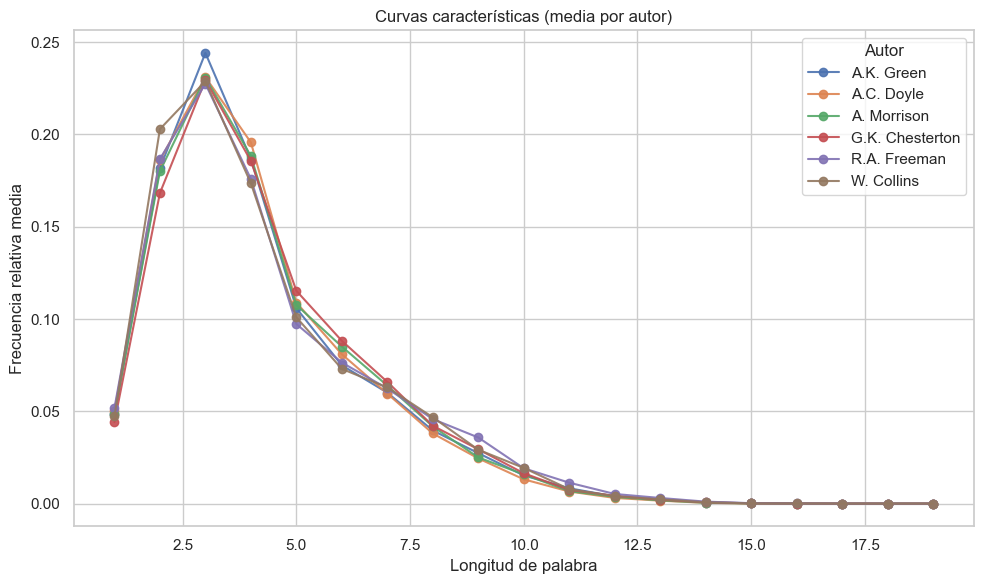

In [19]:
average_curves = {}

# Calculamos la curva media por autor
for author in AUTHORS_ABREV_MAP.keys():
    distributions = author_distributions[author]
    average_curve = compute_average_curve(distributions)
    average_curves[author] = average_curve

# Definimos un eje x común (todas las longitudes
# que aparezcan en cualquier autor)
all_lengths = sorted({L for curve in average_curves.values() for L in curve.keys()})

# Visualizamos todas las curvas en la misma figura
plt.figure(figsize=(10, 6))

for author, curve in average_curves.items():
    x = all_lengths
    y = [curve.get(L, 0.0) for L in x]
    label = AUTHORS_ABREV_MAP.get(author, author)
    plt.plot(x, y, label=label, marker="o", alpha=0.9)

plt.xlabel("Longitud de palabra")
plt.ylabel("Frecuencia relativa media")
plt.title("Curvas características (media por autor)")
plt.grid(True)
plt.legend(title="Autor", loc="upper right")
plt.tight_layout()
plt.show()

Por último, comparamos cuantitativamente entre sí las curvas medias de Mendenhall de todos los autores. Para ello, primero alineamos las distribuciones para que todas queden representadas sobre el mismo rango de longitudes de palabra. Después, calculamos la distancia de Jensen-Shannon entre cada par de curvas medias, obteniendo una matriz de distancias. Finalmente, transformamos esa matriz en un DataFrame etiquetado con los nombres de los autores donde los valores más bajos indican autores con perfiles medios más parecidos, mientras que los más altos señalan una mayor diferencia en la composición de la longitud de palabra entre los autores.

In [20]:
# Alineamos las curvas medias para que tengan la misma longitud
aligned, lengths = align_distributions(average_curves.values())

# Calculamos la matriz de distancias entre las curvas medias
D = distance_matrix(aligned)

# Transformamos la matriz de distancias en un DataFrame
# etiquetado con los nombres de los autores
pd.DataFrame(D, columns=AUTHORS_ABREV_MAP.values(), index=AUTHORS_ABREV_MAP.values())

,A.K. Green,A.C. Doyle,A. Morrison,G.K. Chesterton,R.A. Freeman,W. Collins
A.K. Green,0.000000,0.021842,0.020349,0.028455,0.033224,0.029853
A.C. Doyle,0.021842,0.000000,0.016425,0.031148,0.046617,0.038698
A. Morrison,0.020349,0.016425,0.000000,0.019443,0.039315,0.032797
G.K. Chesterton,0.028455,0.031148,0.019443,0.000000,0.040205,0.041006
R.A. Freeman,0.033224,0.046617,0.039315,0.040205,0.000000,0.026211
W. Collins,0.029853,0.038698,0.032797,0.041006,0.026211,0.000000


La comparación entre las curvas medias de Mendenhall muestra que algunos autores presentan patrones más parecidos entre sí que otros. Los valores más bajos de la matriz de distancias se observan entre Arthur Morrison y G. K. Chesterton, así como entre Arthur Morrison y Arthur Conan Doyle, lo que indica que estos autores presentan distribuciones medias de longitud de palabra relativamente similares. Anna Katharine Green también se sitúa cerca de este grupo, con distancias moderadas respecto a Doyle y Morrison.

Por el contrario, Richard Austin Freeman y Wilkie Collins forman un par relativamente próximo entre sí, pero más alejado del resto de autores. En particular, Freeman registra algunas de las distancias más altas de la matriz, especialmente con Doyle, lo que sugiere un patrón estilístico bastante diferente según esta métrica.

Estos resultados indican que las curvas características de composición de Mendenhall permiten identificar afinidades parciales entre autores y detectar ciertos patrones de agrupamiento, aunque no separaciones absolutas. Así, parece que la distribución media de longitudes de palabra se revela como un rasgo útil para comparar perfiles estilísticos globales dentro del corpus, pero con limitaciones en su capacidad para discriminar de forma tajante entre autores.

### Test de atribución basado en las curvas de Mendenhall

Aún teniendo en cuenta lo limitado que es el análisis de las curvas características de composición de Mendenhall para discriminar entre autores, a continuación proponemos un test de atribución basado en esta métrica. El objetivo es evaluar si la distancia de Jensen-Shannon entre la curva media de un autor y la curva media de un texto desconocido puede servir como criterio para atribuir dicho texto a uno de los autores del corpus.

Para ello, vamos a utilizar los textos de cada autor que habíamos apartado y no habían sido incluidos en el conjunto de bloques utilizados para calcular las curvas medias. Estos textos, que forman el conjunto de prueba, se van a procesar de la misma manera que los bloques anteriores para obtener su distribución de longitudes de palabra.

A continuación, se calculará la distancia de Jensen-Shannon entre la curva media de cada autor y la curva del texto desconocido y, el autor cuya curva media presente la distancia más baja con respecto al texto desconocido, se considerará el candidato más probable para la atribución.

Por último, se evaluará la precisión de este test de atribución comprobando si el autor asignado coincide con el autor real del texto desconocido.

In [21]:
# Cargamos los textos del conjunto de prueba
corpus_by_author_test = load_test_by_dataframe(df_test)
corpus_by_author_test.keys()

dict_keys(['Anna Katharine Green_akg-room_number_3_and_other_detective_stories', 'Anna Katharine Green_akg-to_the_minute', 'Arthur Conan Doyle_acd-the_hound_of_the_baskervilles', 'Arthur Conan Doyle_acd-the_white_company', 'Arthur Morrison_am-adventures_of_martin_hewitt', 'Arthur Morrison_am-the_hole_in_the_wall', 'Gilbert Keith Chesterton_gkc-the_napoleon_of_notting_hill', 'Gilbert Keith Chesterton_gkc-the_poet_and_the_lunatics', 'Richard Austin Freeman_raf-the_exploits_of_danby_croke', 'Richard Austin Freeman_raf-the_shadow_of_the_wolf', 'Wilkie Collins_wc-man_and_wife', 'Wilkie Collins_wc-the_haunted_hotel'])

In [22]:
# Normalizamos y tokenizamos los textos del conjunto de prueba
# igual que hicimos con los textos del corpus de cada autor
author_test_tokens = {}

for author, text in corpus_by_author_test.items():
    toks = []
    tokens_all = tokenizer.tokenize(normalize_text_for_tokenization(fix_gutenberg_linebreaks(text)))
    tokens_alpha = is_alpha_tokens(tokens_all, keep_alpha=True)
    toks.extend(tokens_alpha)
    author_test_tokens[author] = toks
    print(f"{author}: {toks[:20]} ... ({len(toks)} tokens)")

Anna Katharine Green_akg-room_number_3_and_other_detective_stories: ['ROOM', 'NUMBER', 'AND', 'OTHER', 'DETECTIVE', 'STORIES', 'ROOM', 'NUMBER', 'I', 'What', 'door', 'is', 'that', "You've", 'opened', 'all', 'the', 'others', 'why', 'do'] ... (104421 tokens)
Anna Katharine Green_akg-to_the_minute: ['TO', 'THE', 'MINUTE', 'SCARLET', 'AND', 'BLACK', 'TWO', 'TALES', 'OF', "LIFE'S", 'PERPLEXITIES', 'TO', 'THE', 'MINUTE', 'Chapter', 'I', 'Set', 'The', 'Clock', 'There'] ... (39645 tokens)
Arthur Conan Doyle_acd-the_hound_of_the_baskervilles: ['THE', 'HOUND', 'OF', 'THE', 'BASKERVILLES', 'Chapter', 'Mr', 'Sherlock', 'Holmes', 'Mr', 'Sherlock', 'Holmes', 'who', 'was', 'usually', 'very', 'late', 'in', 'the', 'mornings'] ... (59478 tokens)
Arthur Conan Doyle_acd-the_white_company: ['THE', 'WHITE', 'COMPANY', 'CHAPTER', 'I.', 'HOW', 'THE', 'BLACK', 'SHEEP', 'CAME', 'FORTH', 'FROM', 'THE', 'FOLD', 'The', 'great', 'bell', 'of', 'Beaulieu', 'was'] ... (152259 tokens)
Arthur Morrison_am-adventures_of_m

In [23]:
# Asignamos las tokens de los textos de prueba al
# DataFrame para poder trabajar con ellos
df_test["tokens"] = df_test["file_name"].apply(lambda x: get_work_key(author_test_tokens, x))

In [24]:
# Clasificamos los textos de prueba por autor utilizando
# la curva media de cada autor y la distancia mínima
# entre distribuciones de longitud de palabra como
# criterio de clasificación
results_df = classify_test_works_by_average_curve(
    df_test=df_test,
    average_curves=average_curves,
    token_col="tokens",
    title_col="title",
    true_author_col="author",
    block_size=5000,
    n_blocks=20,
    max_len=20,
    seed=SEED,
)

results_df

,row_id,title,true_author,pred_author,min_distance,dist_Anna Katharine Green,dist_Arthur Conan Doyle,dist_Arthur Morrison,dist_Gilbert Keith Chesterton,dist_Richard Austin Freeman,dist_Wilkie Collins
0,0,"Room Number 3, and Other Detective Stories",Anna Katharine Green,Anna Katharine Green,0.010119,0.010119,0.027449,0.022961,0.026590,0.033770,0.034740
1,1,The Hound of the Baskervilles,Arthur Conan Doyle,Arthur Conan Doyle,0.019149,0.028911,0.019149,0.029315,0.038888,0.056386,0.046563
2,2,Adventures of Martin Hewit,Arthur Morrison,Arthur Morrison,0.014583,0.024591,0.018900,0.014583,0.023044,0.047794,0.041939
3,3,The Poet and The Lunatics,Gilbert Keith Chesterton,Gilbert Keith Chesterton,0.013487,0.022744,0.022457,0.013578,0.013487,0.038729,0.036765
4,4,The shadow of the Wolf,Richard Austin Freeman,Richard Austin Freeman,0.024756,0.039461,0.052050,0.042524,0.040084,0.024756,0.031896
5,5,The Haunted Hotel,Wilkie Collins,Wilkie Collins,0.039597,0.049185,0.062986,0.053664,0.048894,0.043944,0.039597
6,6,To the Minute,Anna Katharine Green,Anna Katharine Green,0.023693,0.023693,0.030998,0.028547,0.036243,0.032777,0.036947
7,7,The White Company,Arthur Conan Doyle,Arthur Conan Doyle,0.060022,0.072638,0.060022,0.065893,0.069224,0.100998,0.091173
8,8,The Hole in the Wall,Arthur Morrison,Arthur Conan Doyle,0.030129,0.037543,0.030129,0.038171,0.045912,0.064107,0.060617
9,9,The Napoleon of Notting Hill,Gilbert Keith Chesterton,Gilbert Keith Chesterton,0.018469,0.028660,0.029210,0.019635,0.018469,0.043555,0.040036


In [25]:
results_df["correct"] = results_df["true_author"] == results_df["pred_author"]
results_df[["title", "true_author", "pred_author", "min_distance", "correct"]]

,title,true_author,pred_author,min_distance,correct
0,"Room Number 3, and Other Detective Stories",Anna Katharine Green,Anna Katharine Green,0.010119,True
1,The Hound of the Baskervilles,Arthur Conan Doyle,Arthur Conan Doyle,0.019149,True
2,Adventures of Martin Hewit,Arthur Morrison,Arthur Morrison,0.014583,True
3,The Poet and The Lunatics,Gilbert Keith Chesterton,Gilbert Keith Chesterton,0.013487,True
4,The shadow of the Wolf,Richard Austin Freeman,Richard Austin Freeman,0.024756,True
5,The Haunted Hotel,Wilkie Collins,Wilkie Collins,0.039597,True
6,To the Minute,Anna Katharine Green,Anna Katharine Green,0.023693,True
7,The White Company,Arthur Conan Doyle,Arthur Conan Doyle,0.060022,True
8,The Hole in the Wall,Arthur Morrison,Arthur Conan Doyle,0.030129,False
9,The Napoleon of Notting Hill,Gilbert Keith Chesterton,Gilbert Keith Chesterton,0.018469,True


In [26]:
accuracy = results_df["correct"].mean()
print(f"Accuracy: {accuracy:.2%}")

Accuracy: 91.67%


Como vemos, para estos corpus el test de atribución basado en las curvas de Mendenhall funciona sorprendentemente bien, con una precisión del 91.67% en la clasificación de los textos de prueba. El único error que parece haber cometido es el de clasificar la obra _The Hole in the Wall_ de Arthur Morrison como obra de Arthur Conan Doyle, lo que no es del todo sorprendente dado que ambos autores presentan curvas medias de Mendenhall bastante similares.

Esto sugiere que, a pesar de las limitaciones conocidas de esta técnica, la distribución de longitudes de palabra puede actuar como una huella estilística suficientemente distintiva para discriminar entre los autores seleccionados en este caso concreto.

Esto no implica que esta técnica sea infalible o que funcione igual de bien en otros contextos. A pesar de que aquí ha demostrado ser un método útil para la atribución de autoría hay que tomar estos resultados con cautela, ya que podrían no generalizarse a otros conjuntos de autores o textos.

## 2. Método del chi-cuadrado de Kilgariff

El método del chi-cuadrado de Kilgariff es una forma de comparar textos a partir de sus frecuencias léxicas. En estilometría se utiliza para medir hasta qué punto dos textos presentan patrones semejantes o distintos en el uso de ciertas palabras y, a partir de ello, estimar su cercanía estilística. Su aplicación es especialmente útil en tareas de atribución de autoría, ya que permite comparar una obra de prueba con varios corpus de referencia y asignarla al autor cuya distribución léxica resulte más próxima.

La idea básica es que, si dos textos tienen un estilo parecido, las palabras más frecuentes, y en particular las palabras funcionales, deberían aparecer en proporciones similares. Si esas proporciones difieren de forma sistemática, esa divergencia puede interpretarse como una señal de distancia estilística. El método no compara el contenido semántico del texto, sino hábitos de uso lingüístico como, por ejemplo, la frecuencia relativa con la que un autor emplea palabras como *and*, *but*, *that*, *of* o *to*, así como la proporción de artículos, pronombres, preposiciones o conjunciones.

Kilgariff propuso usar una versión de la prueba de chi-cuadrado para comparar dos perfiles de frecuencia. El procedimiento general es el siguiente:

1. Se selecciona un conjunto de palabras para la comparación.
2. Se cuenta cuántas veces aparece cada una de esas palabras en el corpus de referencia y en el texto de prueba.
3. Para cada palabra, se calcula la diferencia entre la frecuencia observada y la frecuencia esperada si ambos textos siguieran una misma distribución.
4. Se suman esas discrepancias parciales en una estadística global de chi-cuadrado.

La fórmula general es la habitual del chi-cuadrado:

$$
\chi^2 = \sum \frac{(O - E)^2}{E}
$$

donde:

* `O` = frecuencia observada
* `E` = frecuencia esperada

En este contexto, para cada palabra se parte de sus recuentos observados en el corpus de autor y en el texto de prueba. A partir del número total de tokens de cada muestra y de la frecuencia total combinada de esa palabra, se estima cuántas ocurrencias cabría esperar en cada texto si ambos compartieran la misma distribución. Cuanto mayor sea la diferencia entre los valores observados y esperados, mayor será la contribución de esa palabra al valor total de chi-cuadrado. El resultado final puede interpretarse como una medida de distancia: valores bajos indican mayor similitud entre las distribuciones léxicas, mientras que valores altos indican mayor diferencia.

En este tipo de análisis suele trabajarse con *functional words* o palabras gramaticales, también conocidas como *stopwords* (artículos, preposiciones, conjunciones, pronombres, etc.). Se prefieren porque dependen menos del tema tratado y reflejan mejor hábitos de escritura relativamente estables del autor. Si se incluyeran muchas palabras de contenido, la comparación podría verse sesgada por el tema del texto en lugar de por su estilo.

Además, en este notebook utilizaremos un vocabulario común o global para todas las comparaciones. Esto significa que el conjunto de palabras que se empleará como rasgos no se construye de nuevo para cada par corpus-texto, sino que se fija una sola vez a partir del conjunto de entrenamiento, seleccionando las palabras funcionales más frecuentes que superen un umbral mínimo de aparición. La ventaja de este procedimiento es que todas las distancias se calculan sobre exactamente el mismo conjunto de rasgos lingüísticos, de modo que los resultados son más consistentes y comparables entre sí. Si el vocabulario cambiara en cada comparación, el valor de la distancia dependería no solo de las diferencias reales entre los textos, sino también de qué palabras concretas hubieran entrado en esa comparación particular.

Por tanto, el procedimiento que seguiremos en la práctica será el siguiente. En primer lugar, partimos de los tokens de los corpus de entrenamiento y de los textos de prueba. Después, convertimos todos los tokens a minúsculas para evitar que una misma palabra aparezca contada por separado según esté escrita con mayúscula o minúscula, por ejemplo al comienzo de una oración. Esta normalización puede introducir alguna pequeña ambigüedad en casos concretos, como cuando coinciden un nombre propio y un nombre común, pero en general mejora la consistencia del recuento.

A continuación, filtramos los tokens y conservamos únicamente las palabras funcionales incluidas en nuestra lista de *stopwords*. Con los corpus de entrenamiento ya filtrados, construimos un vocabulario global formado por las palabras funcionales más frecuentes, pudiendo además exigir una frecuencia mínima para excluir palabras demasiado raras. Una vez fijado este vocabulario, para cada texto de prueba calculamos su distancia chi-cuadrado respecto a cada corpus de autor usando siempre ese mismo conjunto de palabras. Finalmente, ordenamos las distancias obtenidas y atribuimos el texto al autor cuyo corpus produzca el valor de chi-cuadrado más bajo.

Este enfoque presenta varias ventajas. Es relativamente simple de implementar, funciona bien como medida exploratoria de distancia estilística y permite inspeccionar qué palabras concretas contribuyen más a las diferencias entre textos. Sin embargo, también tiene limitaciones. Sus resultados dependen del tamaño y de la representatividad de las muestras, de modo que los textos muy cortos pueden ofrecer resultados menos fiables. Asimismo, la elección del vocabulario influye directamente en la calidad de la comparación: si se incluyen palabras demasiado raras o demasiado ligadas al contenido temático, puede introducirse ruido. Por esta razón, conviene trabajar con un conjunto controlado de palabras funcionales frecuentes y con un vocabulario fijo para todo el experimento.

Como regla general, cuanto mayor y más equilibrado sea el corpus de entrenamiento, más robusta será la estimación del perfil léxico de cada autor. Del mismo modo, cuanto más estable y representativo sea el vocabulario seleccionado, más fiable será la comparación entre los textos de prueba y los corpus de referencia.

In [27]:
# Nos quedamos solo con las palabras funcionales (stopwords)
# para cada autor en el corpus de entrenamiento
corpus_by_author_functional = {}

for author, tokens in corpus_by_author_tokens.items():
    corpus_by_author_functional[author] = [t.lower() for t in tokens if t.lower() in STOPWORDS]


# Nos quedamos solo con las palabras funcionales
# (stopwords) para cada texto de prueba
author_test_functional = {}

for author, tokens in author_test_tokens.items():
    author_test_functional[author] = [t.lower() for t in tokens if t.lower() in STOPWORDS]

In [28]:
# Clasificamos los textos de prueba utilizando
# el método del chi-cuadrado de Kilgariff
results = classify_test_works_kilgariff(
    corpora=corpus_by_author_functional,
    test_works=author_test_functional,
    vocab_size=300,
    min_freq=1,
)

In [29]:
# Creamos un DataFrame con los resultados de la clasificación
rows = []

for k, info in results.items():
    ranking = dict(info["ranking"])
    true_author = k.split("_")[0]
    file_name = "_".join(k.split("_")[1:]) + ".txt"
    rows.append(
        {
            "title": df_test[df_test["file_name"] == file_name]["title"].values[0],
            "true_author": true_author,
            "pred_author": info["prediccion"],
            "min_distance": min(ranking.values()),
            **{f"dist_{a.split('_')[0]}": ranking.get(a.split("_")[0]) for a in results.keys()},
            "correct": info["prediccion"] == true_author,
        }
    )

results_k_df = pd.DataFrame(rows)
results_k_df

,title,true_author,pred_author,min_distance,dist_Anna Katharine Green,dist_Arthur Conan Doyle,dist_Arthur Morrison,dist_Gilbert Keith Chesterton,dist_Richard Austin Freeman,dist_Wilkie Collins,correct
0,"Room Number 3, and Other Detective Stories",Anna Katharine Green,Anna Katharine Green,1244.031588,1244.031588,8109.873067,9013.651188,15085.073671,10848.900480,7108.927545,True
1,To the Minute,Anna Katharine Green,Anna Katharine Green,1273.485165,1273.485165,5026.913100,7626.803869,10823.188610,6088.775896,3530.494273,True
2,The Hound of the Baskervilles,Arthur Conan Doyle,Arthur Conan Doyle,719.226701,5546.177914,719.226701,4731.780299,7237.568889,4435.797586,7542.659185,True
3,The White Company,Arthur Conan Doyle,Arthur Conan Doyle,10058.389959,19978.714656,10058.389959,11688.184611,16701.477742,18552.533571,20790.536250,True
4,Adventures of Martin Hewit,Arthur Morrison,Arthur Morrison,1484.799453,7018.351676,4730.644010,1484.799453,3717.946502,4468.264457,7901.736049,True
5,The Hole in the Wall,Arthur Morrison,Arthur Morrison,3798.667101,15151.223309,9385.203262,3798.667101,8485.027103,11659.451722,13341.849393,True
6,The Napoleon of Notting Hill,Gilbert Keith Chesterton,Gilbert Keith Chesterton,2642.329129,7034.967528,3815.746781,3150.685056,2642.329129,4284.607170,6695.657763,True
7,The Poet and The Lunatics,Gilbert Keith Chesterton,Gilbert Keith Chesterton,601.639824,9443.716714,6590.635667,3077.379225,601.639824,6033.039365,10758.124985,True
8,The Exploits of Danby Croker,Richard Austin Freeman,Richard Austin Freeman,3568.097829,9253.488990,6205.050584,4653.235188,8683.649771,3568.097829,8021.425789,True
9,The shadow of the Wolf,Richard Austin Freeman,Richard Austin Freeman,2568.897255,7497.673048,4811.428342,3359.223632,3866.206628,2568.897255,9406.518516,True


In [30]:
accuracy = results_k_df["correct"].mean()
print(f"Accuracy: {accuracy:.2%}")

Accuracy: 100.00%


Parece que este segundo método también ha funcionado muy bien a la hora de clasificar las obras, ya que todas las obras de prueba han sido atribuidas correctamente a su autor real.

Además, en la mayoría de los casos la distancia mínima al autor correcto es claramente inferior a la del segundo candidato, lo que indica que la clasificación no solo es correcta, sino también bastante sólida. Los casos de Arthur Conan Doyle y Gilbert Keith Chesterton, en concreto las pertenecientes al género de la novela de misterio, muestran una correspondencia especialmente fuerte entre la obra de prueba y el corpus de referencia, mientras que Richard Austin Freeman y Wilkie Collins presentan distancias mínimas algo más altas, aunque siguen siendo claramente identificables.

Por lo que vemos, el género de la novela parece ser un factor que contribuye a la distancia de similitud estilística entre las obras de prueba y los corpus de referencia, siendo estas distancias bastante menores para las obras de misterio que para las de no misterio para todos los autores, lo que sugiere que el género puede influir en la distribución léxica y, por tanto, en la distancia calculada por el método de Kilgariff.

También se observa cierta proximidad relativa entre algunos autores, especialmente entre Arthur Morrison, Gilbert Keith Chesterton y Richard Austin Freeman, pero sin que esto llegue a generar errores de atribución. En conjunto, los resultados sugieren que el chi-cuadrado de Kilgariff, aplicado sobre palabras funcionales y con un vocabulario global, permite discriminar eficazmente entre los perfiles estilísticos de los autores analizados.

Además de obtener una distancia global de chi-cuadrado para cada comparación entre corpus y texto de prueba, resulta útil examinar qué palabras concretas están contribuyendo más a esa distancia. Para ello utilizamos la función `get_pairwise_contributions()`, que amplía el procedimiento anterior y calcula, para cada par obra–autor, no solo el valor total de chi-cuadrado, sino también el desglose de la contribución individual de cada palabra del vocabulario global.

La función recibe los corpus de entrenamiento y los textos de prueba ya tokenizados, construye primero un vocabulario global común a partir de los corpus de referencia y, a continuación, compara cada obra de prueba con cada corpus de autor mediante la función `kilgariff_chi2()`. El resultado es un diccionario anidado en el que, para cada obra y para cada autor, se almacenan dos elementos: el valor total de chi-cuadrado (`chi2`) y la lista de contribuciones por palabra (`contributions`). Cada contribución incluye la palabra analizada, su aportación parcial al chi-cuadrado y los valores observados y esperados tanto en el corpus como en el texto de prueba.

Esto permite ir más allá de la simple atribución final y entender de dónde proviene la distancia entre dos textos. En concreto, las filas que se imprimen a continuación muestran, para cada autor comparado con su propia obra de prueba, las diez palabras que más han contribuido al valor total de chi-cuadrado. En cada fila, `obsA` representa la frecuencia observada de la palabra en el corpus de entrenamiento, `expA` la frecuencia esperada en ese corpus si ambas muestras siguieran la misma distribución, `obsB` la frecuencia observada en la obra de prueba y `expB` la frecuencia esperada en dicha obra. Cuanto mayor es el valor `chi` de una palabra, mayor es su responsabilidad en la diferencia entre el corpus y el texto analizado.

Por tanto, esta función resulta útil no solo para saber si una obra ha sido correctamente atribuida, sino también para interpretar por qué la distancia con su propio corpus es mayor o menor. Mientras que la tabla de clasificación ofrece una visión global del rendimiento del método, el análisis de contribuciones permite identificar los rasgos léxicos concretos que están acercando o alejando cada texto de su perfil de referencia. En este sentido, constituye una herramienta de diagnóstico muy valiosa para detectar similitudes, desviaciones internas y posibles focos de variación estilística dentro de un mismo autor.

In [31]:
details = get_pairwise_contributions(
    corpora=corpus_by_author_functional,
    test_works=author_test_functional,
    vocab_size=300,
)

In [32]:
for author in details.keys():
    chi2 = details[author][author.split("_")[0]]["chi2"]
    contribs = details[author][author.split("_")[0]]["contributions"]
    print(f"Author: {author}")
    print("Chi2 total:", chi2)
    for row in contribs[:10]:
        token, chi, obs_a, exp_a, obs_b, exp_b = row
        print(f"{token:12} chi={chi:.3f} " f"obsA={obs_a} expA={exp_a:.2f} " f"obsB={obs_b} expB={exp_b:.2f}")
    print(f"\n{'=' * 40}\n")

Author: Anna Katharine Green_akg-room_number_3_and_other_detective_stories
Chi2 total: 1244.0315878267752
you          chi=85.312 obsA=27944 expA=27635.79 obsB=852 expB=1160.21
is           chi=47.440 obsA=13964 expA=13801.58 obsB=417 expB=579.42
our          chi=29.226 obsA=1979 expA=2027.87 obsB=134 expB=85.13
that         chi=26.906 obsA=32618 expA=32430.50 obsB=1174 expB=1361.50
was          chi=26.782 obsA=37757 expA=37959.39 obsB=1796 expB=1593.61
we'll        chi=26.012 obsA=66 expA=74.86 obsB=12 expB=3.14
the          chi=24.411 obsA=125354 expA=125705.62 obsB=5629 expB=5277.38
empty        chi=24.400 obsA=328 expA=346.46 obsB=33 expB=14.54
your         chi=24.006 obsA=5858 expA=5783.21 obsB=168 expB=242.79
toward       chi=23.974 obsA=866 expA=895.41 obsB=67 expB=37.59


Author: Anna Katharine Green_akg-to_the_minute
Chi2 total: 1273.4851650171884
i            chi=220.440 obsA=64129 expA=64606.93 obsB=1531 expB=1053.07
my           chi=156.078 obsA=20562 expA=20790.13 obsB=567

## 3. Método del Delta de Burrows

Una vez implementado el método del chi-cuadrado de Kilgariff, aplicamos también **Delta de Burrows**, una de las métricas más conocidas y utilizadas en estilometría para tareas de atribución de autoría. Su objetivo es medir la distancia estilística entre textos a partir del comportamiento de las palabras más frecuentes, especialmente de las palabras funcionales, que suelen depender menos del contenido temático y reflejar mejor hábitos de escritura relativamente estables.

La idea central del método es que no basta con comparar frecuencias brutas o relativas de palabras, sino que conviene normalizarlas para tener en cuenta cómo se comporta cada palabra en el conjunto del corpus. Para ello, Burrows propone transformar las frecuencias relativas en puntuaciones z. Estas puntuaciones indican cuánto se aleja la frecuencia de una palabra en un texto respecto de la media de esa palabra en el conjunto de referencia, expresándolo en unidades de desviación típica.

El algoritmo original de Burrows se puede resumir de la siguiente manera:

1. Construir un corpus grande compuesto por textos escritos por un número arbitrario de autores $x$.
2. Encontrar las $n$ palabras más frecuentes en el corpus para usarlas como características.
3. Para cada una de estas $n$ características, calcular la proporción de cada uno de los subcorpus de los $x$ autores representados por esta característica, como porcentaje del número total de palabras. Por ejemplo, la palabra “the” podría representar el 4,72 % de las palabras en el subcorpus del Autor A.
4. Luego, calcular la media y la desviación típica de estos valores $x$ y utilizarlos como la media y la desviación típica oficiales para esta característica en todo el corpus. En otras palabras, utilizaremos una media de medias en lugar de calcular un valor único que represente la proporción de todo el corpus representada por cada palabra. Esto se debe a que queremos evitar que un subcorpus más grande, como el de A.K. Green en nuestro caso, influya excesivamente en los resultados a su favor y defina la norma del corpus de tal manera que se esperaría que todo se asemejara a ella.
5. Para cada una de las $n$ características y $x$ subcorpus, calculamos una puntuación $z$ que describa cuán lejos de la norma del corpus se encuentra el uso de esta característica en particular en este subcorpus. Para ello, restamos la “media de medias” de la característica a su frecuencia en el subcorpus y dividimos el resultado entre la desviación estándar de la característica.
6. Luego, calculamos las mismas puntuaciones $z$ para cada característica del texto cuya autoría deseamos determinar.
7. Finalmente, calculamos una puntuación delta comparando la obra de la que queremos determinar su autoría con el subcorpus de cada candidato. Para ello, promediamos los valores absolutos de las diferencias entre las puntuaciones $z$ de cada característica entre la obra anónima y el subcorpus del candidato. Esto otorga el mismo peso a cada característica, independientemente de la frecuencia con la que aparezcan las palabras en los textos, de lo contrario las 3 o 4 características principales predominarían sobre todo lo demás.
8. El candidato “ganador” es el autor para quien la puntuación delta entre el subcorpus del autor y el caso de prueba es la más baja.

La fórmula de la puntuación *z* es la siguiente:

$$
z_{i,j} = \frac{f_{i,j} - \mu_i}{\sigma_i}
$$

donde:

- $f_{i,j}$ es la frecuencia relativa de la palabra $i$ en el texto $j$,
- $\mu_i$ es la media de esa palabra en el conjunto de corpus de entrenamiento,
- $\sigma_i$ es su desviación típica.

Una vez calculadas estas puntuaciones, la distancia Delta entre un texto de prueba y un corpus de referencia se obtiene como la media de las diferencias absolutas entre sus valores *z* para todas las palabras seleccionadas:

$$
\Delta = \frac{1}{n} \sum_{i=1}^{n} |z_{i,\text{prueba}} - z_{i,\text{referencia}}|
$$

donde $n$ es el número de palabras del vocabulario considerado. Como ocurre con otras métricas de distancia, cuanto menor es el valor de Delta, mayor es la semejanza estilística entre los textos comparados.

En este notebook hemos seguido una estrategia análoga a la utilizada en el método de Kilgariff. En primer lugar, partimos de dos diccionarios: uno con los corpus de entrenamiento de cada autor y otro con las obras de prueba. A partir de esos tokens, convertimos todo a minúsculas y conservamos únicamente las palabras funcionales incluidas en nuestra lista de *stopwords*, ya que son las más adecuadas para captar rasgos estilísticos estables y minimizar la influencia del tema.

A continuación, se construye un vocabulario global común a partir de los corpus de entrenamiento. Este vocabulario está formado por las palabras funcionales más frecuentes del conjunto de autores, con un tamaño máximo fijado mediante el parámetro `vocab_size` y, opcionalmente, con un umbral mínimo de frecuencia (`min_freq`) para excluir palabras demasiado raras. El uso de un vocabulario común es importante porque garantiza que todas las comparaciones se realicen sobre exactamente el mismo conjunto de rasgos, haciendo que las distancias sean más consistentes y comparables entre sí. Este conjunto de palabras más frecuentes son las que se usan como características.

Una vez fijado ese vocabulario global, para cada corpus de autor se calculan lasfrecuencias relativas de todas las palabras seleccionadas. A partir de esas frecuencias se obtienen, para cada palabra del vocabulario, su media y su desviación típica en el conjunto de corpus de entrenamiento. Estos dos valores son necesarios para la estandarización en puntuaciones $z$.

Después, cada corpus de autor y cada obra de prueba se representan como un perfil de puntuaciones $z$. Para comparar una obra de prueba con un autor, se calcula la media de las diferencias absolutas entre ambos perfiles. Ese valor es la distancia Delta. El proceso se repite para todos los autores y, finalmente, la obra se atribuye al autor cuyo corpus produce la distancia más baja.

La interpretación de esta métrica es sencilla: cuanto menor es el valor de Delta, más parecidos son los perfiles estilísticos del corpus y de la obra de prueba. Si una obra obtiene su valor mínimo frente al corpus de su autor real, la atribución puede considerarse correcta. Además, si la diferencia entre el mejor candidato y el segundo es amplia, la clasificación puede interpretarse como más sólida.

La ventaja principal de Delta de Burrows es que no compara directamente frecuencias brutas, sino frecuencias normalizadas con respecto al comportamiento general del corpus. Esto hace que la distancia sea más robusta y que palabras con escalas de frecuencia muy distintas puedan contribuir de forma comparable al cálculo final. Además, el método Delta otorga el mismo peso a cada característica que mide, evitando así el problema de que las palabras comunes abrumen los resultados, lo que era un problema con las pruebas de chi-cuadrado. Por esta razón, Delta se ha convertido en uno de los métodos clásicos más importantes de la estilometría moderna.

In [33]:
results_delta = classify_test_works_burrows(
    corpora=corpus_by_author_functional,
    test_works=author_test_functional,
    vocab_size=300,
    min_freq=1,
)

In [34]:
rows = []

for k, info in results_delta.items():
    ranking = dict(info["ranking"])
    true_author = k.split("_")[0]
    file_name = "_".join(k.split("_")[1:]) + ".txt"
    rows.append(
        {
            "title": df_test[df_test["file_name"] == file_name]["title"].values[0],
            "true_author": true_author,
            "pred_author": info["prediccion"],
            "min_distance": min(ranking.values()),
            **{f"dist_{a.split('_')[0]}": ranking.get(a.split("_")[0]) for a in results.keys()},
            "correct": info["prediccion"] == true_author,
        }
    )

results_delta_df = pd.DataFrame(rows)
results_delta_df

,title,true_author,pred_author,min_distance,dist_Anna Katharine Green,dist_Arthur Conan Doyle,dist_Arthur Morrison,dist_Gilbert Keith Chesterton,dist_Richard Austin Freeman,dist_Wilkie Collins,correct
0,"Room Number 3, and Other Detective Stories",Anna Katharine Green,Anna Katharine Green,0.660494,0.660494,1.228359,1.487926,1.459214,1.200702,1.252452,True
1,To the Minute,Anna Katharine Green,Anna Katharine Green,0.914140,0.914140,1.473836,1.789558,1.716073,1.385920,1.362983,True
2,The Hound of the Baskervilles,Arthur Conan Doyle,Arthur Conan Doyle,0.719923,1.146724,0.719923,1.465626,1.412906,1.204705,1.309224,True
3,The White Company,Arthur Conan Doyle,Arthur Conan Doyle,1.589887,1.869468,1.589887,2.127554,2.073450,1.927762,1.913585,True
4,Adventures of Martin Hewit,Arthur Morrison,Arthur Morrison,0.897949,1.582316,1.413188,0.897949,1.340526,1.335252,1.612597,True
5,The Hole in the Wall,Arthur Morrison,Arthur Morrison,1.474394,1.899764,1.887660,1.474394,1.713214,1.904940,1.920992,True
6,The Napoleon of Notting Hill,Gilbert Keith Chesterton,Gilbert Keith Chesterton,1.278132,1.537804,1.383930,1.587803,1.278132,1.475080,1.553156,True
7,The Poet and The Lunatics,Gilbert Keith Chesterton,Gilbert Keith Chesterton,0.634806,1.445400,1.508108,1.405000,0.634806,1.383763,1.529710,True
8,The Exploits of Danby Croker,Richard Austin Freeman,Richard Austin Freeman,1.127675,1.586415,1.423307,1.477062,1.562457,1.127675,1.558772,True
9,The shadow of the Wolf,Richard Austin Freeman,Richard Austin Freeman,0.746213,1.230651,1.168279,1.342732,1.291142,0.746213,1.291525,True


In [35]:
accuracy = results_delta_df["correct"].mean()
print(f"Accuracy: {accuracy:.2%}")

Accuracy: 100.00%


Los resultados obtenidos con Delta de Burrows son muy positivos, ya que todas las obras de prueba han sido atribuidas correctamente a su autor real, alcanzando una exactitud del 100 %. En todas las filas, la distancia mínima corresponde al autor verdadero, lo que indica que el método ha conseguido discriminar con claridad entre los distintos perfiles estilísticos del corpus.

Además del acierto global, conviene observar la diferencia entre la distancia del autor correcto y la de los demás candidatos, porque eso permite valorar la solidez de cada atribución. En general, esa separación es bastante clara. Por ejemplo, en Anna Katharine Green, Arthur Conan Doyle, Gilbert Keith Chesterton y Richard Austin Freeman, la obra de prueba presenta una distancia notablemente menor con su propio corpus que con cualquier otro, lo que sugiere que la clasificación no solo es correcta, sino también estable.

En los casos de Arthur Morrison y Wilkie Collins, las atribuciones también son correctas, aunque las distancias mínimas son algo más altas que en otros autores. Esto sugiere que la correspondencia entre la obra de prueba y el corpus de referencia es algo menos estrecha, pero sigue siendo lo bastante fuerte como para distinguirlas sin ambigüedad del resto de candidatos. Es decir, el método detecta algo más de variación interna en estos casos, pero no hasta el punto de comprometer la atribución.

Vemos que de nuevo el género de la novela parece influir en la distancia de similitud estilística, ya que las obras de misterio presentan distancias menores con su propio corpus que las obras de no misterio para todos los autores, lo que sugiere que el género puede afectar a la distribución léxica y, por tanto, a la distancia calculada por el método Delta.

También hay que tener en cuenta que, en Delta de Burrows, los valores absolutos de la distancia no se interpretan igual que en el chi-cuadrado de Kilgariff. Aquí lo importante no es tanto que una distancia sea “grande” o “pequeña” en términos absolutos, sino su posición relativa dentro del ranking. Lo relevante es que el autor correcto aparece siempre en primera posición y con una ventaja apreciable sobre los demás.

Estos resultados muestran que Delta de Burrows funciona de manera muy eficaz en este experimento. La combinación de palabras funcionales, vocabulario global y normalización mediante puntuaciones $z$ permite captar diferencias estilísticas suficientemente estables como para separar correctamente a los seis autores analizados. Por ello, puede concluirse que esta métrica constituye una herramienta muy útil y fiable para la atribución de autoría en el corpus estudiado.

Además de la clasificación final, resulta útil examinar qué palabras están contribuyendo más a la distancia Delta entre cada obra de prueba y el corpus de su autor. Para ello, se muestran a continuación, y para cada autor y obra, las diez palabras con mayor diferencia entre sus puntuaciones $z$ en el corpus de referencia (`z_ref`) y en la obra de prueba (`z_test`). La columna `diff` representa precisamente esa diferencia absoluta, es decir, cuánto se separa el comportamiento de una palabra entre ambos textos una vez normalizado con respecto al conjunto de entrenamiento.

Esta información permite interpretar con más detalle el valor global de Delta. Un valor total bajo indica que, en conjunto, la obra de prueba se parece bastante al corpus del autor. Din embargo, eso no significa que todas las palabras se comporten de forma idéntica. De hecho, puede ocurrir que la distancia total sea reducida y, aun así, existan algunas palabras concretas con desviaciones muy marcadas. En esos casos, la semejanza general se mantiene, pero aparecen ciertos rasgos léxicos locales que diferencian la obra de prueba del perfil medio del autor.

Lo que muestran estos resultados es que la distancia Delta no suele depender de una diferencia homogénea en todo el vocabulario, sino de un pequeño grupo de palabras cuya frecuencia relativa se aparta más claramente del comportamiento medio esperado. A pesar de ello, en todos los autores la distancia global sigue siendo lo bastante baja como para mantener una atribución correcta. Este análisis confirma, por tanto, que Delta de Burrows no solo clasifica bien las obras de prueba, sino que también permite detectar qué rasgos léxicos concretos explican las pequeñas desviaciones internas de cada texto respecto al perfil de referencia.

In [36]:
details_delta = get_pairwise_burrows_contributions(
    corpora=corpus_by_author_functional,
    test_works=author_test_functional,
    vocab_size=300,
    min_freq=1,
)

for author in details_delta.keys():
    delta = details_delta[author][author.split("_")[0]]["delta"]
    contribs = details_delta[author][author.split("_")[0]]["contributions"]

    print(f"Author: {author}")
    print("Delta:", delta)

    for row in contribs[:10]:
        token, diff, z_ref, z_test = row
        print(f"{token:12} diff={diff:.3f} " f"z_ref={z_ref:.3f} " f"z_test={z_test:.3f}")

    print(f"\n{'=' * 40}\n")

Author: Anna Katharine Green_akg-room_number_3_and_other_detective_stories
Delta: 0.6604935382093033
does         diff=5.878 z_ref=0.462 z_test=-5.416
do           diff=4.011 z_ref=1.453 z_test=-2.558
empty        diff=3.924 z_ref=-0.772 z_test=3.152
them         diff=3.558 z_ref=-0.344 z_test=3.215
either       diff=3.021 z_ref=0.399 z_test=3.421
what         diff=2.936 z_ref=0.248 z_test=-2.688
ours         diff=2.479 z_ref=-0.645 z_test=1.834
you          diff=2.359 z_ref=-0.538 z_test=-2.896
become       diff=2.354 z_ref=0.275 z_test=-2.079
others       diff=2.295 z_ref=0.004 z_test=2.299


Author: Anna Katharine Green_akg-to_the_minute
Delta: 0.9141400873744425
won          diff=8.214 z_ref=1.057 z_test=9.270
ours         diff=7.338 z_ref=-0.645 z_test=6.693
yours        diff=6.125 z_ref=-0.653 z_test=5.472
amount       diff=5.318 z_ref=0.154 z_test=5.472
does         diff=4.945 z_ref=0.462 z_test=-4.484
elsewhere    diff=4.869 z_ref=1.353 z_test=-3.515
both         diff=4.587 z_r